# **Machine Learning & Feature Engineering in Genomics**
### This notebook builds upon our previous analysis of multi-omic data (clinical and copy number alteration data) and introduces machine learning concepts specifically tailored for genomic applications. We'll focus on supervised learning and feature engineering techniques that are particularly relevant for working with biological data.



## 🎯 Learning Objectives
By the end of the class, students will be able to:

- Introduction to Machine Learning in Genomics

- Supervised Learning Overview

- Feature Engineering for Genomic Data

- Practical Implementation

- Project Ideas Development

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, recall_score, f1_score, precision_score, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

 ## 🧭 Introduction

Machine Learning (ML) is a branch of Artificial Intelligence (AI) that allows computers to learn from data and make predictions or decisions without being explicitly programmed. In genomics, ML has become a powerful tool because modern biology generates huge and complex datasets that are difficult to analyze with traditional methods.

**How ML is Changing Genomics**

-Machine learning is transforming genomics by helping scientists and doctors to:

- Predict clinical outcomes – for example, forecasting whether a patient will respond well to a particular treatment.

- Identify biomarkers – features in the genome (like mutations or copy-number changes) that can help classify disease subtypes.

- Discover hidden patterns – finding structure in massive datasets with thousands or millions of genetic features.

- Enable personalized medicine – tailoring treatments to the genetic profile of each patient.

**Why Machine Learning Fits Genomics So Well**

- Lots of features, few samples: A single patient’s genome can contain millions of measurements, but we often only have data for hundreds of patients. ML is designed to handle this imbalance.

- Complex biology: Genes and pathways interact in non-linear ways. ML models can capture these interactions better than simple statistical tests.

- Pattern discovery: ML finds hidden patterns that humans (or basic math) might miss.

- Predictive power: ML doesn’t just explain past data — it can predict new outcomes for unseen patients.

This can be used for **Cancer classification**, **mutation impact prediction**, **copy number alteration profiling**, and **personalized medicine**.

# Types of Machine Learning (with Genomics Examples)

Machine Learning comes in different "flavors," depending on the problem we are trying to solve:

---

## 1. Supervised Learning 🧑‍🏫
- **Definition:** The model learns from labeled data (where the outcome is already known).  
- **Genomics Example:** Predicting whether a tumor is benign or malignant using features like mutation counts or CNV data.  
- **Common Algorithms:** Logistic Regression, Random Forest, Neural Networks  

---

## 2. Unsupervised Learning 🔍
- **Definition:** The model looks for structure in unlabeled data (no outcomes provided).  
- **Genomics Example:** Clustering patients into subtypes based on gene expression or CNV profiles, even if we don’t know the disease labels in advance.  
- **Common Algorithms:** K-means clustering, Hierarchical clustering, PCA  

---

## 3. Reinforcement Learning 🎮
- **Definition:** The model learns by trial and error, receiving rewards for making good decisions.  
- **Genomics Example:** Less common, but could be applied to designing optimal treatment strategies over time.  
- **Common Algorithms:** Q-learning, Policy Gradient methods  

---

## 4. Semi-supervised Learning 🧩
- **Definition:** A mix of supervised and unsupervised learning, used when only part of the data is labeled.  
- **Genomics Example:** If only a few patient samples have known outcomes, ML can still leverage the unlabeled samples to improve predictions.  


👉 In simple terms:

- Supervised = teacher with answer key

- Unsupervised = no teacher, just explore

- Reinforcement = learning by trial and error

- Semi-supervised = little bit of help from a teacher

## Supervised Learning Overview <a name="section2"></a>

Supervised learning involves training models on labeled data to make predictions.  
In our genomic context:

- **Classification**: Predicting categorical outcomes (e.g., survival status, cancer subtype)  
- **Regression**: Predicting continuous values (e.g., mutation count, survival time)  


## 🧼 Data Loading & Initial Inspection

📥 Load the processed and prepared data from last class

In [36]:
df = pd.read_csv('processed_biological_data.csv')
print("Dataset Overview:")
print(df.head())
print(f"\nDataset shape: {df.shape}")



Dataset Overview:
     Patient ID        Sample ID  Mutation Count Overall Survival Status  \
0  TCGA-3C-AAAU  TCGA-3C-AAAU-01            18.0                0:LIVING   
1  TCGA-3C-AALI  TCGA-3C-AALI-01           408.0                0:LIVING   
2  TCGA-3C-AALJ  TCGA-3C-AALJ-01            25.0                0:LIVING   
3  TCGA-3C-AALK  TCGA-3C-AALK-01            40.0                0:LIVING   
4  TCGA-4H-AAAK  TCGA-4H-AAAK-01            15.0                0:LIVING   

                 Cancer Type     Sex  total_segments  mean_seg_mean  \
0  Invasive Breast Carcinoma  Female           657.0       0.206238   
1  Invasive Breast Carcinoma  Female           622.0       0.102380   
2  Invasive Breast Carcinoma  Female           600.0       0.254705   
3  Invasive Breast Carcinoma  Female           150.0      -0.094641   
4  Invasive Breast Carcinoma  Female           172.0      -0.150607   

   gain_segments  loss_segments  frac_gain  frac_loss  
0          340.0          202.0   0.517504

In [37]:
df.isnull().sum()

,0
Patient ID,0
Sample ID,0
Mutation Count,0
Overall Survival Status,0
Cancer Type,0
Sex,0
total_segments,5
mean_seg_mean,5
gain_segments,5
loss_segments,5


In [38]:
df.dropna(inplace=True)

## 3. Feature Engineering for Genomic Data <a name="section3"></a>

Feature engineering is crucial for genomic data because raw biological measurements often need transformation to be useful for ML algorithms.

### Criteria for Effective Feature Selection from Biological Data

- **Biological relevance**: Features should have plausible biological significance  
- **Statistical robustness**: Features should show consistent patterns across samples  
- **Low redundancy**: Avoid highly correlated features that don't add new information  
- **Interpretability**: Features should be understandable to domain experts  
- **Technical reliability**: Features should be measurable with low error rates  


In [39]:
# Create additional engineered features
def engineer_features(dataframe):
    df = dataframe.copy()

    # 1. Create ratio features
    df['gain_loss_ratio'] = df['gain_segments'] / (df['loss_segments'] + 1)  # +1 to avoid division by zero

    # 2. Create interaction terms
    df['mutation_segment_interaction'] = df['Mutation Count'] * df['total_segments']

    # 3. Create categorical encodings
    le = LabelEncoder()
    df['Sex_encoded'] = le.fit_transform(df['Sex'])

    # 4. Create binning for continuous variables
    df['mutation_burden_category'] = pd.cut(df['Mutation Count'],
                                           bins=[0, 50, 200, 500],
                                           labels=['Low', 'Medium', 'High'])

    # 5. Create polynomial features
    df['mean_seg_mean_squared'] = df['mean_seg_mean'] ** 2

    return df

# Apply feature engineering
df_engineered = engineer_features(df)
print("Engineered Features:")
print(df_engineered.head())

Engineered Features:
     Patient ID        Sample ID  Mutation Count Overall Survival Status  \
0  TCGA-3C-AAAU  TCGA-3C-AAAU-01            18.0                0:LIVING   
1  TCGA-3C-AALI  TCGA-3C-AALI-01           408.0                0:LIVING   
2  TCGA-3C-AALJ  TCGA-3C-AALJ-01            25.0                0:LIVING   
3  TCGA-3C-AALK  TCGA-3C-AALK-01            40.0                0:LIVING   
4  TCGA-4H-AAAK  TCGA-4H-AAAK-01            15.0                0:LIVING   

                 Cancer Type     Sex  total_segments  mean_seg_mean  \
0  Invasive Breast Carcinoma  Female           657.0       0.206238   
1  Invasive Breast Carcinoma  Female           622.0       0.102380   
2  Invasive Breast Carcinoma  Female           600.0       0.254705   
3  Invasive Breast Carcinoma  Female           150.0      -0.094641   
4  Invasive Breast Carcinoma  Female           172.0      -0.150607   

   gain_segments  loss_segments  frac_gain  frac_loss  gain_loss_ratio  \
0          340.0     

## 4. Practical Implementation <a name="section4"></a>

Let's implement a complete ML pipeline for survival prediction using our genomic data.


In [40]:
df["Overall Survival Status"].head(15)

,Overall Survival Status
0,0:LIVING
1,0:LIVING
2,0:LIVING
3,0:LIVING
4,0:LIVING
5,0:LIVING
6,0:LIVING
7,0:LIVING
8,0:LIVING
9,0:LIVING


In [41]:
df['Overall Survival Status'].value_counts()

,count
Overall Survival Status,
0:LIVING,946
1:DECEASED,153
Unknown,1


### 🔢 Turning text labels into numbers

Machine‑learning models do maths on numbers — they cannot read text like `"0:LIVING"` or `"1:DECEASED"`. **LabelEncoder** maps each distinct text label to an integer (0, 1, 2, …). Below we encode the survival status, then inspect the counts so we can see exactly which numbers we ended up with.

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_engineered['Overall Survival Status'] = le.fit_transform(df_engineered['Overall Survival Status'])

In [43]:
df_engineered['Overall Survival Status'].value_counts()

,count
Overall Survival Status,
0,946
1,153
2,1


### 🎯 Keeping it a clean binary problem

The encoding produced a stray third class (`2`) from an extra/undefined survival value. To keep this a clean **binary classification** problem — *LIVING* vs *DECEASED* — we drop that small group below. Check the printed counts to see how many patients remain in each class.

In [44]:

df_engineered = df_engineered[df_engineered['Overall Survival Status'] != 2]
print(df_engineered[['Overall Survival Status']].value_counts)

<bound method DataFrame.value_counts of       Overall Survival Status
0                           0
1                           0
2                           0
3                           0
4                           0
...                       ...
1100                        0
1101                        0
1102                        0
1103                        0
1104                        0

[1099 rows x 1 columns]>


## Feature Selection

In [45]:
df_engineered.columns

Index(['Patient ID', 'Sample ID', 'Mutation Count', 'Overall Survival Status',
       'Cancer Type', 'Sex', 'total_segments', 'mean_seg_mean',
       'gain_segments', 'loss_segments', 'frac_gain', 'frac_loss',
       'gain_loss_ratio', 'mutation_segment_interaction', 'Sex_encoded',
       'mutation_burden_category', 'mean_seg_mean_squared'],
      dtype='object')

In [46]:
df_engineered['Cancer Type'].value_counts()

,count
Cancer Type,
Invasive Breast Carcinoma,1099


In [47]:

### Step 1: Data Preparation and Feature Selection

# Prepare features and target
# For classification: Predicting survival status
X = df_engineered[['Mutation Count', 'total_segments', 'mean_seg_mean',
                  'gain_segments', 'loss_segments', 'frac_gain', 'frac_loss',
                  'gain_loss_ratio', 'mutation_segment_interaction', 'Sex_encoded',
                  'mean_seg_mean_squared']]

y = df_engineered['Overall Survival Status']

print("Feature matrix shape:", X.shape)
print(f"Target variable distribution:{y.value_counts()}")


Feature matrix shape: (1099, 11)
Target variable distribution:Overall Survival Status
0    946
1    153
Name: count, dtype: int64


In [48]:
print(y.value_counts())

Overall Survival Status
0    946
1    153
Name: count, dtype: int64


## ⚖️ Class Imbalance in Machine Learning

When one outcome is much more common than the other (e.g. many more *LIVING* than *DECEASED* patients), the dataset is **imbalanced**. A model can then score well simply by always predicting the majority class, while completely failing on the rare‑but‑important cases. Common fixes:

1. **Oversampling** – duplicate examples of the rare class.
2. **Undersampling** – drop examples of the common class.
3. **SMOTE** – *Synthetic Minority Oversampling Technique*: create new, synthetic rare‑class samples by interpolating between real ones.

> ⚠️ **Note:** We *describe* these techniques here but do **not** apply them in this notebook. Keep this in mind when reading the metrics below — and revisit it as an exercise.

### 📏 Why we standardize (scale) the features

Our features live on very different scales: `Mutation Count` is in the hundreds, while `frac_gain` is a fraction between 0 and 1. Models that rely on distances or on the size of coefficients would let the large‑magnitude features dominate, drowning out the small ones.

**StandardScaler** fixes this by converting each feature to a **z‑score**:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the feature's mean and $\sigma$ its standard deviation. After scaling, every feature has **mean 0 and standard deviation 1**, so they all contribute on equal footing.

In [49]:
X.head()

,Mutation Count,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss,gain_loss_ratio,mutation_segment_interaction,Sex_encoded,mean_seg_mean_squared
0,18.0,657.0,0.206238,340.0,202.0,0.517504,0.307458,1.674877,11826.0,0,0.042534
1,408.0,622.0,0.102380,285.0,184.0,0.458199,0.295820,1.540541,253776.0,0,0.010482
2,25.0,600.0,0.254705,304.0,165.0,0.506667,0.275000,1.831325,15000.0,0,0.064875
3,40.0,150.0,-0.094641,28.0,32.0,0.186667,0.213333,0.848485,6000.0,0,0.008957
4,15.0,172.0,-0.150607,23.0,46.0,0.133721,0.267442,0.489362,2580.0,0,0.022682


In [50]:
from sklearn.preprocessing import StandardScaler #MinMaxScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [51]:
X_scaled[0:5]

array([[-0.20744755,  0.55414672,  1.11180667,  1.03973273,  0.52661712,
         1.536683  ,  0.63358836,  0.43346955, -0.13698076, -0.1050693 ,
        -0.04411717],
       [ 1.67940375,  0.49284402,  0.64547623,  0.7814776 ,  0.44247306,
         1.13872047,  0.49185328,  0.28897857,  2.73285518, -0.1050693 ,
        -0.20519584],
       [-0.17358099,  0.4543109 ,  1.32943088,  0.870693  ,  0.35365433,
         1.46396038,  0.23829918,  0.60174415, -0.09933307, -0.1050693 ,
         0.06815641],
       [-0.10100978, -0.3338666 , -0.23916985, -0.42527821, -0.26807681,
        -0.68339976, -0.51270394, -0.45539056, -0.20608456, -0.1050693 ,
        -0.21285836],
       [-0.22196179, -0.29533348, -0.49046107, -0.44875594, -0.20263143,
        -1.03869215,  0.14625291, -0.84166032, -0.24665013, -0.1050693 ,
        -0.14388102]])

### 🌟 Which features matter most?

We can ask a **Random Forest** how useful each feature was. The bar chart below ranks features by how much each one improved the trees' decisions — **longer bars mean more predictive features**. (See the explanation of how a Random Forest works just below.)

### 🌳 How a Random Forest works (and why we trust its rankings)

A **decision tree** splits patients by asking simple yes/no questions on a feature, e.g. *"Is Mutation Count > 50?"*, repeating until each group is mostly one outcome. A single tree easily **overfits** (memorises noise).

A **Random Forest** is an *ensemble*: it grows many trees, each on a random subset of the data and features, then lets them **vote**. Averaging many diverse trees cancels out individual mistakes and generalises better.

A feature gets a high **importance** score when splitting on it repeatedly improves the separation between outcomes across the whole forest — telling biologists *which genomic features actually drive the prediction*.

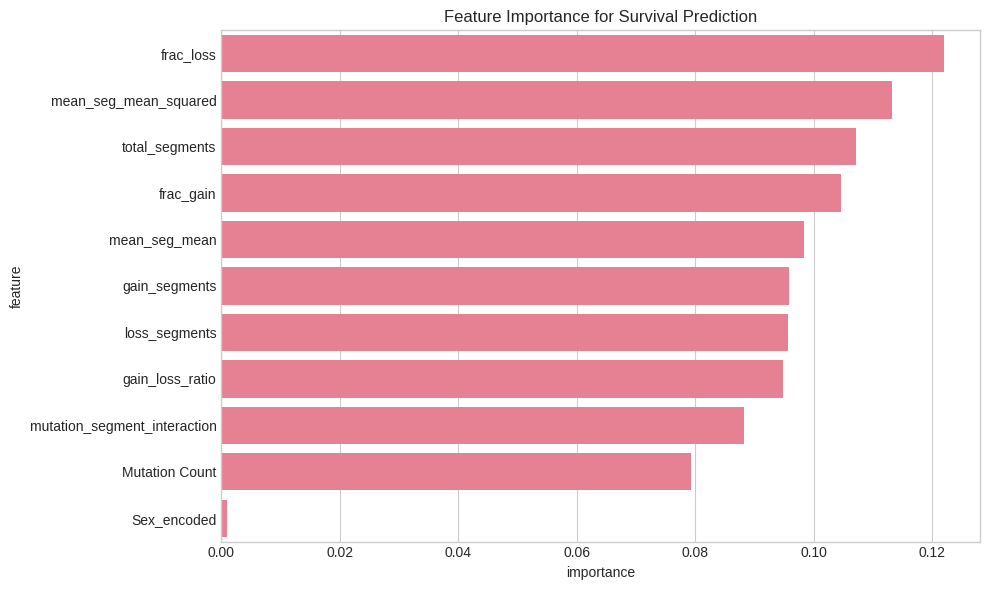

In [52]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train a random forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Get importance scores
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance for Survival Prediction')
plt.tight_layout()
plt.show()


Step 3: Model Training and Evaluation

Now let’s train and test some models (Logistic Regression and Random Forest).

### 🧪 Training, testing, and the two models we compare

**Train/test split.** We hold out 30% of patients as a **test set** the model never sees during training, so our scores reflect performance on *new* patients rather than memorisation. `stratify=y` keeps the LIVING/DECEASED proportions identical in both splits (important for imbalanced data), and `random_state=42` makes the split reproducible.

We train **two contrasting models** on the same data:

**1. Logistic Regression** — a simple, interpretable baseline. It computes a weighted sum of the features, $z$, then passes it through the **sigmoid** function to get a probability between 0 and 1:

$$p = \frac{1}{1 + e^{-z}}$$

If $p > 0.5$ it predicts class 1. The sigmoid is just a smooth S‑curve that turns any score into a probability.

**2. Random Forest** — chosen because it captures **non‑linear interactions** between features that a linear model like logistic regression misses, and it needs no feature scaling (see the tree explanation above).

Training a linear *and* a non‑linear model lets us compare how much the extra complexity actually buys us.

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)


# model Initialization
model_log = LogisticRegression(random_state=42)
model_rf = RandomForestClassifier(random_state=42)

#model fitting or training
model_log.fit(X_train, y_train)
model_rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [54]:
y_log_pred = model_log.predict(X_test)

In [55]:
y_rf_pred = model_rf.predict(X_test)

### ✅ Evaluating the predictions

We now compare each model's predictions on the unseen test set against the true labels. Using a confusion of **TP** (true positives), **FP** (false positives) and **FN** (false negatives):

- **Accuracy** = fraction of all predictions that are correct.
- **Precision** $= \dfrac{TP}{TP + FP}$ — of those predicted positive, how many really are.
- **Recall** $= \dfrac{TP}{TP + FN}$ — of the actual positives, how many we caught.
- **F1** = harmonic mean of precision and recall — one number balancing both.

In [56]:
accuracy = accuracy_score(y_test, y_log_pred)
print(f"Logistic Regression Accuracy: {accuracy:.3f}")

recall = recall_score(y_test, y_log_pred)
print(f"Logistic Regression Recall: {recall:.3f}")

Logistic Regression Accuracy: 0.861
Logistic Regression Recall: 0.022


In [57]:
accuracy = accuracy_score(y_test, y_rf_pred)
print(f"Random Forest Accuracy: {accuracy:.3f}")



Random Forest Accuracy: 0.833


### 📊 Beyond accuracy — choosing the right metric

**Accuracy alone is misleading on imbalanced data.** If 80% of patients are *LIVING*, a model that blindly predicts *LIVING* for everyone scores 80% accuracy while catching **zero** of the at‑risk patients. That is why we also report:

- **Recall** – of the patients who truly had the outcome, how many did we catch?
- **Precision** – of the patients we flagged, how many were correct?
- **F1 score** – a single number balancing precision and recall.
- **ROC‑AUC** – how well the model ranks positives above negatives across all thresholds.

The class counts below show exactly how imbalanced our target is — which is why these extra metrics matter.

In [58]:
y.value_counts()

,count
Overall Survival Status,
0,946
1,153


5. Project Ideas Development <a name="section5"></a>

Here are three beginner-friendly project ideas you can try with genomic data:

Project 1: Survival Analysis Prediction

Goal: Predict whether a patient survives or not using genomic features.

In [ ]:
from sklearn.metrics import classification_report

def survival_analysis_pipeline(df):
    # Select features
    features = ['Mutation Count', 'total_segments', 'mean_seg_mean',
                'gain_segments', 'loss_segments', 'frac_gain', 'frac_loss',
                'Sex_encoded']

    X = df[features]
    y = df['Overall Survival Status']

    # Handle missing values
    X = X.fillna(X.mean())

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train Random Forest
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Survival Prediction Accuracy: {accuracy:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Feature importance
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    return model, importance_df

# Run pipeline
survival_model, feature_importance = survival_analysis_pipeline(df_engineered)
print("\nTop features for survival prediction:")
print(feature_importance.head())


Project 2: Cancer Subtype Classification

Goal: Predict the type of cancer from genomic features.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Simulate cancer subtypes for demo
df_simulated = df_engineered.copy()
df_simulated['Cancer_Type_Simulated'] = np.random.choice(['BRCA', 'LUAD', 'COAD'], size=len(df_simulated))

def subtype_classification_pipeline(df):
    # Encode target
    le = LabelEncoder()
    y = le.fit_transform(df['Cancer_Type_Simulated'])

    # Select features
    features = ['Mutation Count', 'total_segments', 'mean_seg_mean',
                'gain_segments', 'loss_segments', 'frac_gain', 'frac_loss',
                'Sex_encoded']

    X = df[features].fillna(df[features].mean())

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train Random Forest with cross-validation
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

    print(f"Subtype Classification CV Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

    return cv_scores.mean()

subtype_accuracy = subtype_classification_pipeline(df_simulated)


Project 3: Mutation Burden Prediction

Goal: Predict the number of mutations (a continuous value).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def mutation_burden_prediction(df):
    # Features and target
    features = ['total_segments', 'mean_seg_mean', 'gain_segments',
                'loss_segments', 'frac_gain', 'frac_loss', 'Sex_encoded']

    X = df[features]
    y = df['Mutation Count']

    # Handle missing values
    X = X.fillna(X.mean())
    y = y.fillna(y.mean())

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42
    )

    # Train regression model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mutation Burden Prediction MSE: {mse:.3f}")
    print(f"Mutation Burden Prediction R²: {r2:.3f}")

    # Plot predictions vs actual
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Mutation Count')
    plt.ylabel('Predicted Mutation Count')
    plt.title('Mutation Burden Prediction: Actual vs Predicted')
    plt.show()

    return model, mse, r2

mutation_model, mse, r2 = mutation_burden_prediction(df_engineered)
